In [1]:
import torchvision
import torch
import torchvision.transforms as transforms
import os
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import random
from torch.utils.data import Dataset, DataLoader
from google.colab import drive
from tqdm import tqdm
!pip install pytorch-msssim -q
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms.functional as TF
from pytorch_msssim import ssim as compute_ssim
import math

In [3]:
#Kindly keep the dataset in the google drive and allow the permission to access it.
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Copy Dataset to Local SSD
import shutil

if os.path.exists('/content/dataset'):
    print("Dataset already exists on local SSD, skipping copy.")
else:
    print("Copying dataset to local SSD...")
    shutil.copytree(
        '/content/drive/MyDrive/Colab Notebooks/dataset',
        '/content/dataset'
    )
    print("Done!")

HR = '/content/dataset/HR'
LR = '/content/dataset/LR'

Copying dataset to local SSD...
Done!


In [5]:
def show_img(folder_path, class_name):
    files = sorted(os.listdir(folder_path))

    # pick first 6 images
    selected_files = files[:6]

    plt.figure(figsize=(8,2))

    for i, file_name in enumerate(selected_files):
        file_path = os.path.join(folder_path, file_name)

        image = np.load(file_path).squeeze()

        plt.subplot(1, 6, i+1)
        plt.imshow(image, cmap='gray')
        plt.title(file_name, fontsize=8)
        plt.axis('off')

    plt.suptitle(f"Class: {class_name}", fontsize=14)
    plt.tight_layout()
    plt.show()

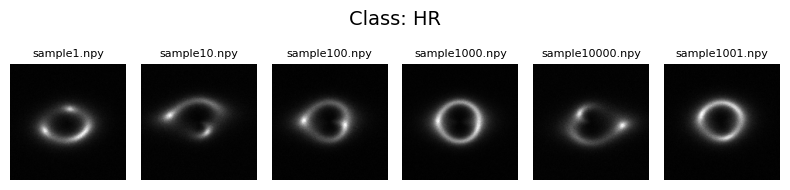

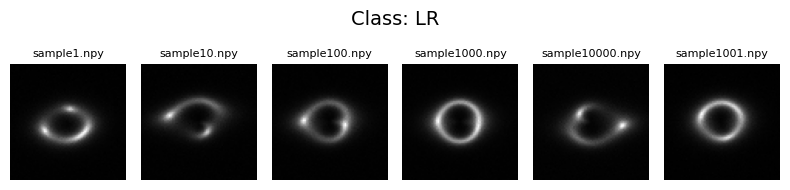

In [6]:
show_img(HR, 'HR')
show_img(LR, 'LR')

In [7]:
DEVICE     = 'cuda' if torch.cuda.is_available() else 'cpu'
BATCH_SIZE = 64
VAL_SPLIT  = 0.1
SEED       = 42
SAVE_DIR   = '/content/drive/MyDrive/Colab Notebooks/sr_checkpoints'
LR_RATE    = 3e-4

os.makedirs(SAVE_DIR, exist_ok=True)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"Device: {DEVICE}")

Device: cuda


In [8]:
from torchvision import transforms

augment_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
])

def apply_paired(transform, lr, hr):
    # Same seed forces the same random choices on both LR and HR
    seed = random.randint(0, 99999)
    torch.manual_seed(seed)
    lr_aug = transform(lr)
    torch.manual_seed(seed)
    hr_aug = transform(hr)
    return lr_aug, hr_aug

test_lr = torch.randn(1, 75, 75)
test_hr = torch.randn(1, 150, 150)
aug_lr, aug_hr = apply_paired(augment_transform, test_lr, test_hr)
print(f"LR after aug: {aug_lr.shape} | HR after aug: {aug_hr.shape}")

LR after aug: torch.Size([1, 75, 75]) | HR after aug: torch.Size([1, 150, 150])


In [9]:
class LensingDataset(Dataset):
    def __init__(self, lr_files, hr_files, augment=False):
        self.lr_files = lr_files
        self.hr_files = hr_files
        self.augment  = augment

    def __len__(self):
        return len(self.lr_files)

    def minmax(self, arr):
        mn, mx = arr.min(), arr.max()
        return torch.tensor((arr - mn) / (mx - mn + 1e-8), dtype=torch.float32)

    def __getitem__(self, idx):
        lr = self.minmax(np.load(self.lr_files[idx]))  # (1, 75, 75)
        hr = self.minmax(np.load(self.hr_files[idx]))  # (1, 150, 150)

        if self.augment:
            lr, hr = apply_paired(augment_transform, lr, hr)

        return lr, hr

In [10]:
lr_files = sorted([os.path.join(LR, f) for f in os.listdir(LR) if f.endswith('.npy')])
hr_files = sorted([os.path.join(HR, f) for f in os.listdir(HR) if f.endswith('.npy')])

idx = list(range(len(lr_files)))
random.shuffle(idx)
n_val = int(len(idx) * VAL_SPLIT)
val_idx, train_idx = idx[:n_val], idx[n_val:]

train_ds = LensingDataset([lr_files[i] for i in train_idx], [hr_files[i] for i in train_idx], augment=True)
val_ds   = LensingDataset([lr_files[i] for i in val_idx],   [hr_files[i] for i in val_idx],   augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)}")
lr_b, hr_b = next(iter(train_loader))
print(f"LR batch: {lr_b.shape} | HR batch: {hr_b.shape}")

Train: 9000 | Val: 1000
LR batch: torch.Size([64, 1, 75, 75]) | HR batch: torch.Size([64, 1, 150, 150])


In [11]:
class ResBlock(nn.Module):
    def __init__(self, channels=64):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.relu  = nn.ReLU(inplace=True)

    def forward(self, x):
        out = self.relu(self.conv1(x))
        out = self.conv2(out)
        return x + out

class Generator(nn.Module):
    def __init__(self, channels=64, n_blocks=8):
        super().__init__()
        self.head = nn.Conv2d(1, channels, kernel_size=3, padding=1)

        self.body = nn.Sequential(*[ResBlock(channels) for _ in range(n_blocks)])

        # Upsample: learn to go from 75x75 to 150x150
        self.upsample = nn.Sequential(
            nn.Conv2d(channels, channels * 4, kernel_size=3, padding=1),
            nn.PixelShuffle(2),
            nn.ReLU(inplace=True),
        )

        self.tail = nn.Conv2d(channels, 1, kernel_size=3, padding=1)

    def forward(self, x):
        head_out = self.head(x)
        body_out = self.body(head_out)
        out      = head_out + body_out
        out      = self.upsample(out)
        out      = torch.sigmoid(self.tail(out))
        return out


G = Generator(channels=64, n_blocks=8).to(DEVICE)
test_out = G(torch.randn(1, 1, 75, 75).to(DEVICE))
print(f"Output shape : {test_out.shape}")
print(f"Params       : {sum(p.numel() for p in G.parameters())/1e6:.2f}M")

Output shape : torch.Size([1, 1, 150, 150])
Params       : 0.74M


In [13]:
def total_loss(sr, hr):
    mse_loss  = F.mse_loss(sr, hr)
    ssim_loss = 1.0 - compute_ssim(sr, hr, data_range=1.0, size_average=True)
    return mse_loss + 0.3 * ssim_loss


def calc_psnr(sr, hr):
    mse = F.mse_loss(sr, hr).item()
    return 10 * math.log10(1.0 / (mse + 1e-10))


@torch.no_grad()
def evaluate(G, loader):
    G.eval()
    mse_vals, ssim_vals, psnr_vals = [], [], []
    for lr_b, hr_b in loader:
        lr_b, hr_b = lr_b.to(DEVICE), hr_b.to(DEVICE)
        sr = G(lr_b).clamp(0, 1)
        mse_vals.append(F.mse_loss(sr, hr_b).item())
        ssim_vals.append(compute_ssim(sr, hr_b, data_range=1.0, size_average=True).item())
        psnr_vals.append(calc_psnr(sr, hr_b))
    return np.mean(mse_vals), np.mean(ssim_vals), np.mean(psnr_vals)

In [14]:
# Pretrain
PRETRAIN_EPOCHS = 30

opt_g = torch.optim.Adam(G.parameters(), lr=LR_RATE)

history = {'mse': [], 'ssim': [], 'psnr': [], 'loss': []}
best_ssim = 0.0

print("=" * 50)
print("Pixel Pretraining")
print("=" * 50)

try:
    for epoch in range(1, PRETRAIN_EPOCHS + 1):
        G.train()
        epoch_loss = 0.0

        for lr_b, hr_b in tqdm(train_loader, desc=f"Epoch {epoch}/{PRETRAIN_EPOCHS}", leave=False):
            lr_b, hr_b = lr_b.to(DEVICE), hr_b.to(DEVICE)
            opt_g.zero_grad()
            sr   = G(lr_b)
            loss = total_loss(sr, hr_b)
            loss.backward()
            opt_g.step()
            epoch_loss += loss.item()

        mse, ssim, psnr = evaluate(G, val_loader)
        history['loss'].append(epoch_loss / len(train_loader))
        history['mse'].append(mse)
        history['ssim'].append(ssim)
        history['psnr'].append(psnr)

        print(f"Epoch {epoch:3d}/{PRETRAIN_EPOCHS} | Loss: {epoch_loss/len(train_loader):.4f} | MSE: {mse:.5f} | SSIM: {ssim:.4f} | PSNR: {psnr:.2f}dB")

        if ssim > best_ssim:
            best_ssim = ssim
            torch.save({'epoch': epoch, 'G': G.state_dict()},
                       os.path.join(SAVE_DIR, 'pretrain_best.pth'))
            print(f"  → Saved best (SSIM: {ssim:.4f})")

# I can stop the training if the metric have reached the desired amount or if they have converged
except KeyboardInterrupt:
    print("\nInterrupted — saving checkpoint...")
    torch.save({'epoch': epoch, 'G': G.state_dict()},
               os.path.join(SAVE_DIR, 'interrupted.pth'))
    print("Saved.")

print(f"\nBest SSIM: {best_ssim:.4f}")

Pixel Pretraining


Epoch   1/30 | Loss: 0.0461 | MSE: 0.00164 | SSIM: 0.9391 | PSNR: 27.98dB
  → Saved best (SSIM: 0.9391)


Epoch   2/30 | Loss: 0.0225 | MSE: 0.00154 | SSIM: 0.9423 | PSNR: 28.28dB
  → Saved best (SSIM: 0.9423)


Epoch   3/30 | Loss: 0.0221 | MSE: 0.00148 | SSIM: 0.9390 | PSNR: 28.44dB


Epoch   4/30 | Loss: 0.0219 | MSE: 0.00149 | SSIM: 0.9422 | PSNR: 28.43dB


...

Epoch  17/30 | Loss: 0.0200 | MSE: 0.00144 | SSIM: 0.9483 | PSNR: 28.58dB


Epoch  18/30 | Loss: 0.0200 | MSE: 0.00144 | SSIM: 0.9472 | PSNR: 28.59dB


Epoch  19/30 | Loss: 0.0200 | MSE: 0.00145 | SSIM: 0.9486 | PSNR: 28.57dB


Epoch  20/30 | Loss: 0.0199 | MSE: 0.00144 | SSIM: 0.9487 | PSNR: 28.58dB
  → Saved best (SSIM: 0.9487)



Interrupted — saving checkpoint...
Saved.

Best SSIM: 0.9487


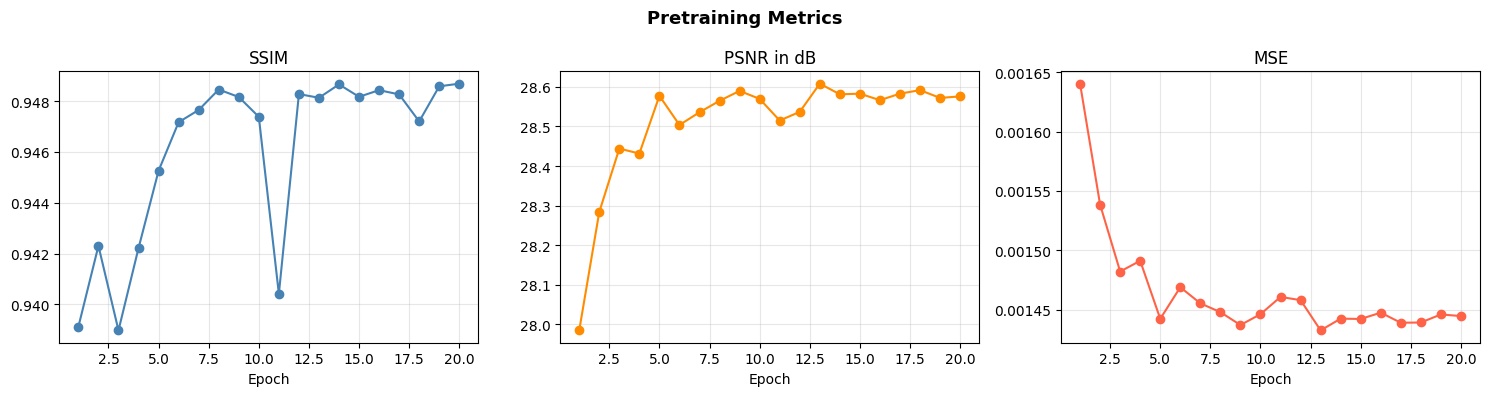

In [15]:
epochs = list(range(1, len(history['ssim']) + 1))
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(epochs, history['ssim'], marker='o', color='steelblue')
axes[0].set_title('SSIM')
axes[0].set_xlabel('Epoch')
axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history['psnr'], marker='o', color='darkorange')
axes[1].set_title('PSNR in dB')
axes[1].set_xlabel('Epoch')
axes[1].grid(alpha=0.3)

axes[2].plot(epochs, history['mse'], marker='o', color='tomato')
axes[2].set_title('MSE')
axes[2].set_xlabel('Epoch')
axes[2].grid(alpha=0.3)

plt.suptitle('Pretraining Metrics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

Loaded best checkpoint from epoch 20

  MSE  : 0.001444
  SSIM : 0.9487
  PSNR : 28.58 dB


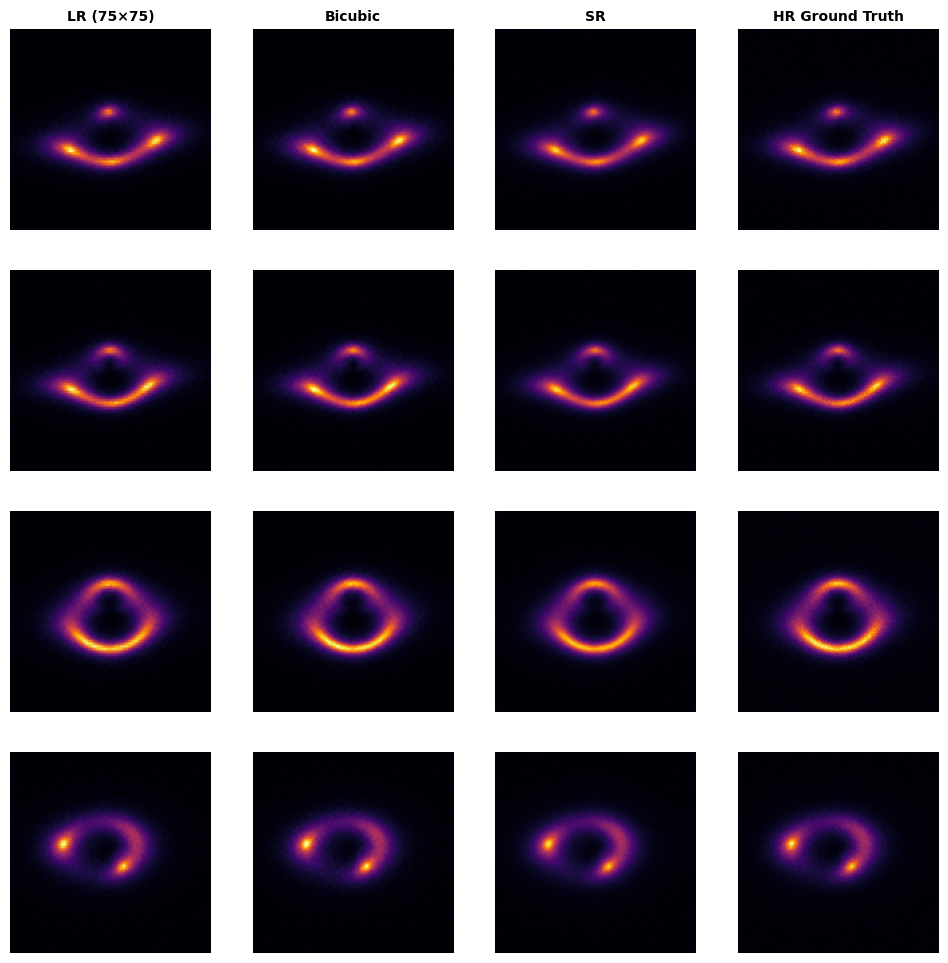

In [16]:
ckpt = torch.load(os.path.join(SAVE_DIR, 'pretrain_best.pth'), map_location=DEVICE)
G.load_state_dict(ckpt['G'])
print(f"Loaded best checkpoint from epoch {ckpt['epoch']}")

mse, ssim, psnr = evaluate(G, val_loader)
print(f"\n{'='*40}")
print(f"  MSE  : {mse:.6f}")
print(f"  SSIM : {ssim:.4f}")
print(f"  PSNR : {psnr:.2f} dB")
print(f"{'='*40}")

G.eval()
lr_b, hr_b = next(iter(val_loader))
with torch.no_grad():
    sr_b = G(lr_b.to(DEVICE)).clamp(0, 1).cpu()
bicubic = F.interpolate(lr_b, scale_factor=2, mode='bicubic', align_corners=False).clamp(0, 1)

n = 4
fig, axes = plt.subplots(n, 4, figsize=(12, 3 * n))

for col, title in enumerate(['LR (75×75)', 'Bicubic', 'SR', 'HR Ground Truth']):
    axes[0, col].set_title(title, fontsize=10, fontweight='bold')

for i in range(n):
    for col, img in enumerate([lr_b[i,0], bicubic[i,0], sr_b[i,0], hr_b[i,0]]):
        axes[i, col].imshow(img.numpy(), cmap='inferno', vmin=0, vmax=1)
        axes[i, col].axis('off')

plt.show()